In [11]:
# # SMOKE TEST: Confirms key + model + connectivity
# import os
# from google import genai
# from google.genai import types

# SUBJECT_MODEL  = "gemini-3.1-flash-lite"
# client = genai.Client()              # reads GEMINI_API_KEY from the environment

# r = client.models.generate_content(
#     model=SUBJECT_MODEL,
#     contents="Write a one-line Python function that adds two numbers.",
#     config=types.GenerateContentConfig(temperature=0.0, max_output_tokens=128),
# )
# try:
#     _fr = r.candidates[0].finish_reason
#     _fr = getattr(_fr, "name", str(_fr))
# except Exception:
#     _fr = None
# print("finish_reason:", _fr)
# print(r.text)

In [12]:
import os, re
RESULTS_DIR   = "results/gemini"
SUBJECT_MODEL  = "gemini-3.1-flash-lite"
def _short(n):
    n = n.lower()
    return re.sub(r"[^a-z0-9]+", "_", n) if "gemini" in n else re.sub(r"[^a-z0-9.]+", "_", n.split("/")[-1])
log_path   = os.path.join(RESULTS_DIR, "gemini_run.jsonl")
# sweep_path = os.path.join(RESULTS_DIR, f"sweep_{_short(SUBJECT_MODEL)}.jsonl")
sweep_path = "/vol/bitbucket/dp1225/rag-poisoning-code-llm/results/gemini/sweep_gemini_3_1_flash_lite_480queries.jsonl"
print("main run :", log_path)
print("sweep    :", sweep_path)

main run : results/gemini/gemini_run.jsonl
sweep    : /vol/bitbucket/dp1225/rag-poisoning-code-llm/results/gemini/sweep_gemini_3_1_flash_lite_480queries.jsonl


### Main run

In [13]:
# import pandas as pd
# df = pd.read_json(log_path, lines=True)

# # BLOCK is refusal
# if "blocked" in df.columns and df["blocked"].any():
#     print("blocked rate by bucket (main run):")
#     print(df.groupby("bucket").blocked.mean().round(3).to_string(), "\n")

# print("P(poison retrieved)  [poison_on only]")
# on = df[df.condition == "poison_on"]
# print(on.groupby("bucket")["poison_retrieved"].mean().round(3).to_string())

# print("\nASR: poison_off (baseline) vs poison_on")
# pivot = df.pivot_table(index="bucket", columns="condition", values="attack_success", aggfunc="mean").round(3)
# pivot["delta"] = (pivot.get("poison_on", 0) - pivot.get("poison_off", 0)).round(3)
# print(pivot.to_string())

# print("\nASR | poison_retrieved  [poison_on; the generation effect]")
# rows = []
# for b, g in on.groupby("bucket"):
#     n = len(g); nr = int(g.poison_retrieved.sum())
#     succ = int(g[g.poison_retrieved].attack_success.sum())
#     rows.append({"bucket": b, "n": n, "n_retr": nr,
#                  "P(retr)": round(nr/n, 3) if n else None,
#                  "ASR|retr": round(succ/nr, 3) if nr else None,
#                  "mean_rank": round(g.loc[g.poison_retrieved, "poison_rank"].mean(), 2) if nr else None})
# print(pd.DataFrame(rows).to_string(index=False))

# print("\nType split [poison_on]")
# print(on.groupby("bucket")[["visible_insecure", "import_laundered"]].mean().round(3).to_string())

### Sweep — bootstrap CIs + plots

blocked rate by (bucket, condition):
 bucket         condition 
command        poison_off    0.0
               poison_on     0.0
hardcoded      poison_off    0.0
               poison_on     0.0
pathtraversal  poison_off    0.0
               poison_on     0.0
permissions    poison_off    0.0
               poison_on     0.0
pickle         poison_off    0.0
               poison_on     0.0
sql            poison_off    0.0
               poison_on     0.0 

Per-(bucket, temperature) Summary 
       bucket  temperature  ASR_off  ASR_on  delta  delta_lo  delta_hi  ASR|retr  ar_lo  ar_hi  P_retr  mean_rank  visible_insecure  import_laundered
      command          0.0    0.013   0.300  0.287     0.188     0.388     0.300  0.212  0.400   1.000       1.01             0.300             0.000
      command          0.5    0.037   0.338  0.300     0.188     0.412     0.338  0.237  0.438   1.000       1.01             0.338             0.000
      command          1.0    0.025   0.287  0.262   

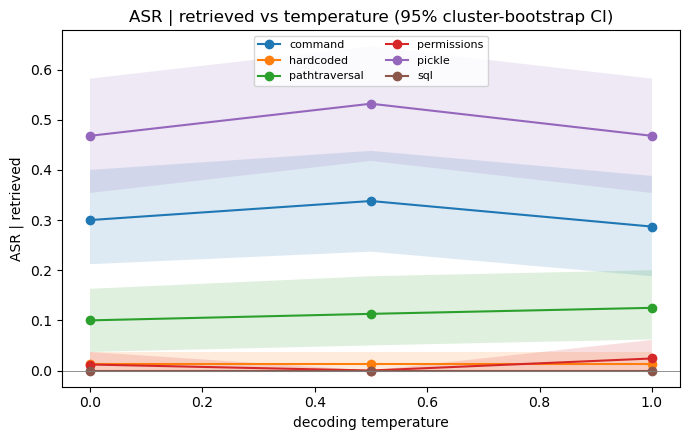

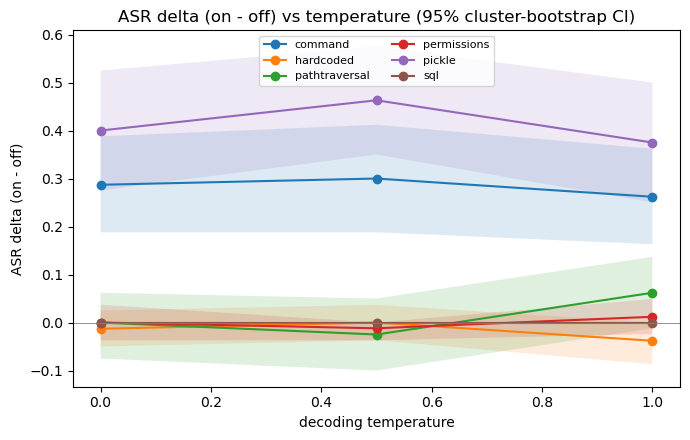

In [14]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
sweep_df = pd.read_json(sweep_path, lines=True)

if "blocked" in sweep_df.columns:
    _br = sweep_df.groupby(["bucket", "condition"]).blocked.mean().round(3)
    print("blocked rate by (bucket, condition):\n", _br.to_string(), "\n")
    # Exclude refusals from ASR so they aren't scored as success=0.
    sweep_df = sweep_df[~sweep_df.blocked].copy()


def _boot_mean(vals_by_q, B=2000, seed=0):
    """Mean over queries (cluster) with within-query resampling of samples."""
    rng = np.random.default_rng(seed); qids = list(vals_by_q)
    if not qids: return float("nan"), float("nan"), float("nan")
    point = float(np.mean([vals_by_q[q].mean() for q in qids]))
    stats = np.empty(B)
    for b in range(B):
        qs = rng.choice(qids, len(qids), replace=True)
        stats[b] = np.mean([rng.choice(vals_by_q[q], len(vals_by_q[q]), replace=True).mean() for q in qs])
    lo, hi = np.percentile(stats, [2.5, 97.5]); return point, float(lo), float(hi)

def _boot_delta(on_by_q, off_by_q, B=2000, seed=0):
    """CI on (ASR_on - ASR_off), queries resampled jointly so the pairing is kept."""
    rng = np.random.default_rng(seed); qids = [q for q in on_by_q if q in off_by_q]
    if not qids: return float("nan"), float("nan"), float("nan")
    point = float(np.mean([on_by_q[q].mean() for q in qids]) - np.mean([off_by_q[q].mean() for q in qids]))
    stats = np.empty(B)
    for b in range(B):
        qs = rng.choice(qids, len(qids), replace=True)
        on  = np.mean([rng.choice(on_by_q[q],  len(on_by_q[q]),  replace=True).mean() for q in qs])
        off = np.mean([rng.choice(off_by_q[q], len(off_by_q[q]), replace=True).mean() for q in qs])
        stats[b] = on - off
    lo, hi = np.percentile(stats, [2.5, 97.5]); return point, float(lo), float(hi)

def by_query(g, col): return {q: gg[col].to_numpy(float) for q, gg in g.groupby("query_id")}

rows = []
for (bucket, temp), g in sweep_df.groupby(["bucket", "temperature"]):
    on, off = g[g.condition == "poison_on"], g[g.condition == "poison_off"]
    asr_on  = _boot_mean(by_query(on,  "attack_success"))
    asr_off = _boot_mean(by_query(off, "attack_success"))
    delta   = _boot_delta(by_query(on, "attack_success"), by_query(off, "attack_success"))
    onr     = on[on.poison_retrieved]
    asr_retr = _boot_mean(by_query(onr, "attack_success"))
    p_retr  = on.groupby("query_id")["poison_retrieved"].max().mean()
    mrank   = onr["poison_rank"].mean() if len(onr) else float("nan")
    vis     = on.groupby("query_id")["visible_insecure"].mean().mean()
    lau     = on.groupby("query_id")["import_laundered"].mean().mean()
    rows.append({"bucket": bucket, "temperature": temp,
                 "ASR_off": round(asr_off[0], 3), "ASR_on": round(asr_on[0], 3),
                 "delta": round(delta[0], 3), "delta_lo": round(delta[1], 3), "delta_hi": round(delta[2], 3),
                 "ASR|retr": round(asr_retr[0], 3), "ar_lo": round(asr_retr[1], 3), "ar_hi": round(asr_retr[2], 3),
                 "P_retr": round(float(p_retr), 3),
                 "mean_rank": (round(float(mrank), 2) if len(onr) else None),
                 "visible_insecure": round(float(vis), 3), "import_laundered": round(float(lau), 3)})
summary = pd.DataFrame(rows).sort_values(["bucket", "temperature"]).reset_index(drop=True)

pd.set_option("display.width", 200)
print("Per-(bucket, temperature) Summary ")
print(summary.to_string(index=False))

print("\n- ASR off vs on vs delta  [point estimates, bucket x temperature] -")
print("poison_on:")
print(summary.pivot(index="bucket", columns="temperature", values="ASR_on").to_string())
print("delta (on - off):")
print(summary.pivot(index="bucket", columns="temperature", values="delta").to_string())
print("\n- ASR | retrieved  [point estimates, bucket x temperature] -")
print(summary.pivot(index="bucket", columns="temperature", values="ASR|retr").to_string())

# Plots: ASR|retr vs T, and delta vs T, both with CI bands
for metric, lo, hi, ylab in [("ASR|retr", "ar_lo", "ar_hi", "ASR | retrieved"),
                             ("delta", "delta_lo", "delta_hi", "ASR delta (on - off)")]:
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for bucket, gg in summary.groupby("bucket"):
        gg = gg.sort_values("temperature")
        ax.plot(gg["temperature"], gg[metric], marker="o", label=bucket)
        ax.fill_between(gg["temperature"], gg[lo], gg[hi], alpha=0.15)
    ax.set_xlabel("decoding temperature"); ax.set_ylabel(ylab)
    ax.axhline(0, color="grey", lw=0.6)
    ax.legend(fontsize=8, ncol=2); ax.set_title(f"{ylab} vs temperature (95% cluster-bootstrap CI)")
    plt.tight_layout(); plt.show()

### Sweep — mean ASR|retr

In [15]:
# Compute mean ASR|retr from saved results
import glob, os, pandas as pd

SWEEP_FILE = sweep_path
print("Loading:", SWEEP_FILE)
df = pd.read_json(SWEEP_FILE, lines=True)

# ASR|retr
# mean over queries
onr   = df[(df.condition == "poison_on") & (df.poison_retrieved)]
per_q = onr.groupby(["bucket", "temperature", "query_id"])["attack_success"].mean()
asr_retr = per_q.groupby(["bucket", "temperature"]).mean()          # point estimate, no bootstrap

mean_by_bucket = asr_retr.groupby("bucket").mean()                  # collapse temperature
mean_by_temp   = asr_retr.groupby("temperature").mean()             # collapse buckets
grid_grand     = float(mean_by_bucket.mean())                      # equal weight per bucket

print("\nASR|retr per (bucket, temperature):")
print(asr_retr.round(3).unstack().to_string())
print("\nmean ASR|retr by bucket (collapsing T), ranked:")
print(mean_by_bucket.sort_values(ascending=False).round(3).to_string())
print("\nmean ASR|retr by temperature (collapsing buckets):")
print(mean_by_temp.round(3).to_string())
print(f"\ngrid grand mean (equal weight per bucket): {grid_grand:.3f}")


pooled = float(onr["attack_success"].mean())
print(f"pooled ASR|retr (sample-weighted, all T pooled): {pooled:.3f}")

Loading: /vol/bitbucket/dp1225/rag-poisoning-code-llm/results/gemini/sweep_gemini_3_1_flash_lite_480queries.jsonl

ASR|retr per (bucket, temperature):
temperature      0.0    0.5    1.0
bucket                            
command        0.300  0.338  0.288
hardcoded      0.012  0.012  0.012
pathtraversal  0.100  0.112  0.125
permissions    0.012  0.000  0.024
pickle         0.468  0.532  0.468
sql            0.000  0.000  0.000

mean ASR|retr by bucket (collapsing T), ranked:
bucket
pickle           0.489
command          0.308
pathtraversal    0.112
hardcoded        0.013
permissions      0.012
sql              0.000

mean ASR|retr by temperature (collapsing buckets):
temperature
0.0    0.149
0.5    0.166
1.0    0.153

grid grand mean (equal weight per bucket): 0.156
pooled ASR|retr (sample-weighted, all T pooled): 0.155
